In [3]:
import pandas as pd
import numpy as np
import glob
import os

# ==========================================
# STAGE 1 & 2: DEFINITION & LOADING
# ==========================================

# Trip Data

In [4]:
data_path = r'bikeshare ridership/'

In [5]:
all_files = glob.glob(os.path.join(data_path, "*2024*.csv"))
print(f"Found {len(all_files)} files: {all_files}")

# 3. Loop through and load them into one list
li = []
for filename in all_files:
    # Use encoding='latin1' to fix the UTF-8 error
    # Use low_memory=False to handle large columns correctly
    df = pd.read_csv(filename, encoding='latin1', low_memory=False)
    
    # Clean column names immediately (removes weird spaces)
    df.columns = [c.strip().replace('  ', ' ').lower().replace(' ', '_') for c in df.columns]
    
    li.append(df)
    print(f"✅ Loaded: {os.path.basename(filename)}")

Found 3 files: ['bikeshare ridership\\Bike share ridership 2024-07.csv', 'bikeshare ridership\\Bike Share ridership 2024-08.csv', 'bikeshare ridership\\Bike Share ridership 2024-09.csv']
✅ Loaded: Bike share ridership 2024-07.csv
✅ Loaded: Bike Share ridership 2024-08.csv
✅ Loaded: Bike Share ridership 2024-09.csv


In [6]:
#4. Concatenate everything into one giant 5M+ row DataFrame
full_df = pd.concat(li, axis=0, ignore_index=True)

print(f"\n🚀 Total rows loaded: {len(full_df):,}")
print(full_df.head())


🚀 Total rows loaded: 2,707,927
      trip_id  trip_duration  start_station_id     start_time  \
0  29706718.0            611              7199  7/1/2024 0:00   
1  29706719.0           3592              7242  7/1/2024 0:00   
2  29706722.0            630              7199  7/1/2024 0:00   
3  29706723.0            578              7018  7/1/2024 0:00   
4  29706724.0            503              7045  7/1/2024 0:00   

               start_station_name  end_station_id       end_time  \
0         College St / Markham St            7718  7/1/2024 0:10   
1  Lake Shore Blvd W / Ontario Dr            7707  7/1/2024 0:59   
2         College St / Markham St            7718  7/1/2024 0:10   
3          Bremner Blvd / Rees St            7176  7/1/2024 0:09   
4            Bond St / Queen St E            7489  7/1/2024 0:08   

                         end_station_name  bike_id      user_type    model  \
0            St. Andrew's Playground Park     6267  Casual Member   ICONIC   
1  Coronatio

In [7]:
cols = list(full_df.columns)
cols[0] = 'trip_id_1'
cols[11] = 'trip_id_2'
full_df.columns = cols

In [8]:
full_df['trip_id'] = full_df['trip_id_1'].combine_first(full_df['trip_id_2'])

In [9]:
full_df.drop(columns=['trip_id_1', 'trip_id_2'], inplace=True)

In [10]:
print(f"Missing values: {full_df['trip_id'].isnull().sum()}")

Missing values: 0


In [11]:
full_df.memory_usage()

Index                      128
trip_duration         21663416
start_station_id      21663416
start_time            21663416
start_station_name    21663416
end_station_id        21663416
end_time              21663416
end_station_name      21663416
bike_id               21663416
user_type             21663416
model                 21663416
trip_id               21663416
dtype: int64

In [12]:
# Reducing Memory 
for col in full_df.select_dtypes(include=['int64', 'float64']).columns:
    full_df[col] = pd.to_numeric(full_df[col], downcast='integer' if 'int' in str(full_df[col].dtype) else 'float')

In [13]:
full_df.memory_usage()

Index                      128
trip_duration         10831708
start_station_id       5415854
start_time            21663416
start_station_name    21663416
end_station_id         5415854
end_time              21663416
end_station_name      21663416
bike_id                5415854
user_type             21663416
model                 21663416
trip_id               21663416
dtype: int64

In [14]:
# Convert objects to categories (HUGE savings for station names)
for col in ['start_station_name', 'end_station_name', 'user_type', 'model']:
    full_df[col] = full_df[col].astype('category')

print(full_df.memory_usage())

Index                      128
trip_duration         10831708
start_station_id       5415854
start_time            21663416
start_station_name     5455358
end_station_id         5415854
end_time              21663416
end_station_name       5455374
bike_id                5415854
user_type              2708051
model                  2708059
trip_id               21663416
dtype: int64


In [15]:
# Convert Time to actual datetime objects
full_df['start_time'] = pd.to_datetime(full_df['start_time'])
full_df['end_time'] = pd.to_datetime(full_df['end_time'])

In [16]:
# Check if IDs are floats or ints
print(full_df[['start_station_id', 'end_station_id']].dtypes)

start_station_id    int16
end_station_id      int16
dtype: object


In [17]:
print("Data Date Range:")
print(f"Start: {full_df['start_time'].min()}")
print(f"End:   {full_df['start_time'].max()}")

# Quick check: Do we have any 'backwards' trips? (End before Start)
backwards = full_df[full_df['end_time'] < full_df['start_time']]
print(f"Backwards trips found: {len(backwards)}")

Data Date Range:
Start: 2024-07-01 00:00:00
End:   2024-09-30 23:59:00
Backwards trips found: 0


In [18]:
# Calculate duration in minutes for easier viewing
full_df['duration_min'] = full_df['trip_duration'] / 60

# Filter: Keep only trips between 1 minute and 8 hours
initial_count = len(full_df)
full_df = full_df[(full_df['duration_min'] >= 1) & (full_df['duration_min'] <= 480)].copy()

print(f"Removed {initial_count - len(full_df)} trips (too short or too long).")

Removed 3121 trips (too short or too long).


In [19]:
full_df['is_circular'] = full_df['start_station_id'] == full_df['end_station_id']
print(f"Circular trips (same start/end): {full_df['is_circular'].sum()}")

Circular trips (same start/end): 78109


# Station Data

In [20]:
import json

In [21]:
stations_path = r'toronto-bikeshare/station'

In [22]:
file_path = os.path.join('station', 'stations.json')

try:
    # Open the JSON file directly
    with open(file_path, 'r', encoding='utf-8') as f:
        stations_data = json.load(f)

    # Flatten the JSON into a DataFrame
    stations = pd.json_normalize(stations_data['data']['stations'])
    print(f"📍 Station metadata loaded. {len(stations)} stations identified.")
    
    # Display the first few rows to verify
    display(stations.head())

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at: {os.path.abspath(file_path)}")
    print("Double check if 'toronto-bikeshare' is spelled exactly right (case-sensitive).")

📍 Station metadata loaded. 1001 stations identified.


,station_id,name,physical_configuration,lat,lon,address,capacity,is_charging_station,rental_methods,groups,obcn,short_name,nearby_distance,_ride_code_support,post_code,altitude,is_valet_station,cross_street
0,7000,Fort York Blvd / Capreol Ct,REGULAR,43.639832,-79.395954,Fort York Blvd / Capreol Ct,47,False,"[key, transitcard, creditcard, phone]","[South, Fort York - Entertainment District]",647-643-9607,647-643-9607,500.0,True,NaN,NaN,NaN,NaN
1,7001,Wellesley Station Green P,ELECTRICBIKESTATION,43.664964,-79.383550,Yonge / Wellesley,23,True,"[key, transitcard, creditcard, phone]","[E-Charging , South, Church Wellesley / Yorkvi...",416-617-9576,416-617-9576,500.0,True,M4Y 1G7,NaN,NaN,NaN
2,7002,St. George St / Bloor St W,REGULAR,43.667131,-79.399555,St. George St / Bloor St W,19,False,"[key, transitcard, creditcard, phone]","[South, U of T - Hospital Row]",647-643-9615,647-643-9615,500.0,True,NaN,NaN,NaN,NaN
3,7003,Madison Ave / Bloor St W,REGULAR,43.667018,-79.402796,Madison Ave / Bloor St W,15,False,"[key, transitcard, creditcard, phone]","[South, Bloor St W / Annex]",647-631-4587,647-631-4587,500.0,True,NaN,NaN,NaN,NaN
4,7005,King St W / York St,VAULT,43.648001,-79.383177,King St W / York St,26,False,"[key, transitcard, phone]","[South, Financial District]",647-643-9693,647-643-9693,500.0,True,NaN,0.0,NaN,NaN


In [23]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   station_id              1001 non-null   object 
 1   name                    1001 non-null   object 
 2   physical_configuration  998 non-null    object 
 3   lat                     1001 non-null   float64
 4   lon                     1001 non-null   float64
 5   address                 1000 non-null   object 
 6   capacity                1001 non-null   int64  
 7   is_charging_station     1001 non-null   bool   
 8   rental_methods          998 non-null    object 
 9   groups                  1001 non-null   object 
 10  obcn                    1001 non-null   object 
 11  short_name              1001 non-null   object 
 12  nearby_distance         1001 non-null   float64
 13  _ride_code_support      1001 non-null   bool   
 14  post_code               714 non-null    

In [24]:
stations[['groups']]

,groups
0,"[South, Fort York - Entertainment District]"
1,"[E-Charging , South, Church Wellesley / Yorkvi..."
2,"[South, U of T - Hospital Row]"
3,"[South, Bloor St W / Annex]"
4,"[South, Financial District]"
...,...
996,"[North, North York - York U, North York - Will..."
997,"[North, Thorncliffe Park - Sunnybrook]"
998,[North]
999,[South]


In [25]:
# 1. Rename columns to match our workflow
# (Note: Check your specific JSON keys; they might be 'station_id' or 'id')
rename_dict = {
    'station_id': 'station_id', # change 'station_id' if your JSON uses 'id'
    'capacity': 'capacity'
}
stations = stations.rename(columns=rename_dict)

# 2. Extract District (Sometimes districts are in a nested 'rental_methods' or similar)
# If 'district' isn't a top-level column, let's look for it.
if 'district' not in stations.columns:
    print("⚠️ 'district' not found. Checking for alternative location info...")
    # Some Toronto JSONs use 'address' or 'postcode' if district is missing.
    # For our Tiering logic, we MUST have a district or neighborhood column.

# 3. Cast to match trips (int32)
stations['station_id'] = stations['station_id'].astype('int32')

print("\n✅ Stations JSON Flattened and Standardized.")
print(stations[['station_id', 'capacity']].head())

⚠️ 'district' not found. Checking for alternative location info...

✅ Stations JSON Flattened and Standardized.
   station_id  capacity
0        7000        47
1        7001        23
2        7002        19
3        7003        15
4        7005        26


In [26]:
# Check if 'groups' contains the district info
print("Sample from 'groups' column:")
print(stations['groups'].head(10))

Sample from 'groups' column:
0          [South, Fort York - Entertainment District]
1    [E-Charging , South, Church Wellesley / Yorkvi...
2                       [South, U of T - Hospital Row]
3                          [South, Bloor St W / Annex]
4                          [South, Financial District]
5                       [South, U of T - Hospital Row]
6                       [South, U of T - Hospital Row]
7                       [South, U of T - Hospital Row]
8                          [South, Financial District]
9          [South, Fort York - Entertainment District]
Name: groups, dtype: object


In [27]:
def clean_group_to_district(group_list):
    # Check if it's actually a list and has at least one element
    if isinstance(group_list, list) and len(group_list) > 0:
        # If 'South' or 'North' is first, try to take the second specific name
        if len(group_list) > 1:
            return group_list[1] 
        return group_list[0]
    return "Unknown"

stations['district'] = stations['groups'].apply(clean_group_to_district)

# Now, let's see the unique districts we've "discovered"
print("Cleaned Districts:")
print(stations['district'].unique())

Cleaned Districts:
['Fort York - Entertainment District' 'South' 'U of T - Hospital Row'
 'Bloor St W / Annex' 'Financial District' 'Church Wellesley / Yorkville'
 'Watefront' 'College St - Harbord St' 'Liberty Village - Queen West'
 'Regent Park - Distillery' 'Unknown' 'Danforth' 'Bloor St W - High Park'
 'East' 'Thorncliffe Park - Sunnybrook' 'Leslieville - Woodbine'
 'Davenport - Dupont' 'Annex Efit drop off' 'St Clair Ave W'
 'Humber Bay Shores' 'West' 'Mid Town' 'Eglinton Ave W' 'North'
 'North York - York U' 'Scarborough - St. Clair'
 'Scarborough - Rouge Hill' 'North York - Willowdale' 'Scarborough North'
 'Wexford / Marydale' 'Bendale']


In [28]:
# How many stations are in each district?
district_counts = stations['district'].value_counts()
print("\nStation Counts per District:")
print(district_counts)


Station Counts per District:
district
Financial District                    59
Leslieville - Woodbine                55
Fort York - Entertainment District    50
Liberty Village - Queen West          49
Eglinton Ave W                        47
Church Wellesley / Yorkville          44
North York - York U                   44
Watefront                             43
Bloor St W - High Park                42
Scarborough - Rouge Hill              41
College St - Harbord St               41
Danforth                              39
Thorncliffe Park - Sunnybrook         37
Regent Park - Distillery              37
Davenport - Dupont                    37
Mid Town                              35
Scarborough - St. Clair               34
U of T - Hospital Row                 32
Humber Bay Shores                     32
North York - Willowdale               31
St Clair Ave W                        24
East                                  24
South                                 23
West              

In [29]:
# 1. Standardization Mapping
district_mapping = {
    'Watefront': 'Waterfront',
    'Bloor St W / Annex': 'Annex',
    'Annex Efit drop off': 'Annex',
    'Fort York - Entertainment District': 'Entertainment District',
    'College St - Harbord St': 'College - Harbord',
    'Regent Park - Distillery': 'Distillery District',
    'Liberty Village - Queen West': 'Liberty Village'
}

stations['district'] = stations['district'].replace(district_mapping)

In [30]:
# 2. Handling the "Directional" catch-all (South/North/East/West)
# Let's see if we can use the address to fix "South"
def fix_generic_districts(row):
    if row['district'] in ['South', 'East', 'West', 'North', 'Unknown']:
        # Simple heuristic: if 'Bay' or 'King' or 'Queen' is in address, it's Core
        addr = str(row['address']).lower()
        if any(x in addr for x in ['bay st', 'king st', 'queen st', 'front st']):
            return 'Core-Correction'
    return row['district']

stations['district'] = stations.apply(fix_generic_districts, axis=1)

print("Updated District Counts (Post-Standardization):")
print(stations['district'].value_counts().head(10))

Updated District Counts (Post-Standardization):
district
Financial District              59
Leslieville - Woodbine          55
Entertainment District          50
Liberty Village                 49
Eglinton Ave W                  47
Church Wellesley / Yorkville    44
North York - York U             44
Waterfront                      43
Bloor St W - High Park          42
Scarborough - Rouge Hill        41
Name: count, dtype: int64


In [31]:
# Do we have any stations in 'full_df' that ended up as 'Unknown' or 'Core-Correction'?
trips_per_district = full_df.merge(stations[['station_id', 'district']], 
                                   left_on='start_station_id', 
                                   right_on='station_id')['district'].value_counts()

print("\nTrip Volume per District:")
print(trips_per_district.head(15))


Trip Volume per District:
district
Entertainment District          318708
Financial District              305868
Waterfront                      281662
Church Wellesley / Yorkville    239032
U of T - Hospital Row           203212
Liberty Village                 192614
College - Harbord               180935
Distillery District             177452
Annex                           132288
Leslieville - Woodbine          115279
South                            83643
Davenport - Dupont               64394
Humber Bay Shores                56313
Danforth                         47978
Mid Town                         43105
Name: count, dtype: int64


In [32]:
# Identify the 'South' stations that have the most trips
south_stations = stations[stations['district'] == 'South']['station_id']
south_trip_check = full_df[full_df['start_station_id'].isin(south_stations)]

# Look at the station names for these 'South' trips
print("Top 'South' Stations by Volume:")
print(south_trip_check.groupby('start_station_name').size().sort_values(ascending=False).head(10))

Top 'South' Stations by Volume:
start_station_name
Wellesley Station Green P                     11138
Temperance St Station                         10682
The Well                                       9762
University Ave / Gerrard St W (East Side)      9469
Huron St / Harbord St                          7905
Elizabeth St / Elm St                          7686
Queens Quay W / Dan Leckie Way                 6333
Simcoe St / Dundas St W - SMART                6144
Ursula Franklin St / St. George St - SMART     5623
Elm St/ University Ave (East Side)             3645
dtype: int64


C:\Users\yz571\AppData\Local\Temp\ipykernel_41192\2459479144.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(south_trip_check.groupby('start_station_name').size().sort_values(ascending=False).head(10))


In [33]:
# 1. Define the Tiering Logic based on our deep inspection
def assign_tier(district):
    # Tier 1: The High-Pressure Core (Sinks)
    tier_1_districts = [
        'Financial District', 'Entertainment District', 'Waterfront', 
        'U of T - Hospital Row', 'Distillery District', 'Church Wellesley / Yorkville'
    ]
    
    # Tier 2: The Commuter Feeders (Sources)
    tier_2_districts = [
        'Liberty Village', 'Annex', 'College - Harbord', 
        'Leslieville - Woodbine', 'Davenport - Dupont', 'Danforth'
    ]
    
    if district in tier_1_districts:
        return 'Tier-1-Core'
    if district in tier_2_districts:
        return 'Tier-2-Feeder'
    
    return 'Tier-3-Ignore'

In [34]:
# 2. Apply it to the stations lookup
stations['tier'] = stations['district'].apply(assign_tier)

# 3. CRITICAL CLEAN: Force 'South' stations we verified into the Core
# Since these names appeared in our 'South' check, we manually promote them
core_names = ['Wellesley Station Green P', 'Temperance St Station', 'The Well', 'University Ave / Gerrard St W']
stations.loc[stations['name'].str.contains('|'.join(core_names), na=False), 'tier'] = 'Tier-1-Core'

print("Final Tier Distribution in Stations:")
print(stations['tier'].value_counts())

Final Tier Distribution in Stations:
tier
Tier-3-Ignore    476
Tier-1-Core      269
Tier-2-Feeder    256
Name: count, dtype: int64


In [35]:
# --- THE FINAL SURGICAL EXPORT ---

# 1. Select the essential columns for the App
# We include 'tier' so the app can highlight your 'Tier-1-Core' stations
export_cols = ['name', 'lat', 'lon', 'district', 'tier', 'capacity']

# 2. Create the clean database
# We use .copy() to avoid any SettingWithCopy warnings
station_db_final = stations[export_cols].copy()

# 3. Save as the Master CSV
station_db_final.to_csv('station_districts_mapped.csv', index=False)

print(f"🚀 Success! Master Station Database saved with {len(station_db_final)} stations.")
print("The 'South' promotions (The Well, University Ave, etc.) are now locked in.")

🚀 Success! Master Station Database saved with 1001 stations.
The 'South' promotions (The Well, University Ave, etc.) are now locked in.


In [36]:
# 1. Merge for Start Station
full_df = full_df.merge(
    stations[['station_id', 'district', 'tier']], 
    left_on='start_station_id', 
    right_on='station_id', 
    how='left'
).rename(columns={'district': 'start_district', 'tier': 'start_tier'}).drop('station_id', axis=1)

In [37]:
# 2. Merge for End Station
full_df = full_df.merge(
    stations[['station_id', 'district', 'tier']], 
    left_on='end_station_id', 
    right_on='station_id', 
    how='left'
).rename(columns={'district': 'end_district', 'tier': 'end_tier'}).drop('station_id', axis=1)

# 3. Apply the Pulse Filter
# Keep the ride IF it starts OR ends in a Tier-1-Core station
pulse_condition = (full_df['start_tier'] == 'Tier-1-Core') | (full_df['end_tier'] == 'Tier-1-Core')
trips_filtered = full_df[pulse_condition].copy()

print(f"Original Trips: {len(full_df)}")
print(f"Pulse-Filtered Trips: {len(trips_filtered)}")
print(f"Noise Removed: {len(full_df) - len(trips_filtered)} trips")

Original Trips: 2704806
Pulse-Filtered Trips: 2039379
Noise Removed: 665427 trips


# Prediction MATH

In [38]:
# 1. Round timestamps to the hour
trips_filtered['time_hour'] = trips_filtered['start_time'].dt.floor('h')

# 2. Departures (Bikes LEAVING a station = Pressure Down)
departures = trips_filtered.groupby(['start_station_id', 'time_hour']).size().reset_index(name='departures')

# 3. Arrivals (Bikes ARRIVING at a station = Pressure Up)
# Use end_time for arrivals to be precise
trips_filtered['end_hour'] = trips_filtered['end_time'].dt.floor('h')
arrivals = trips_filtered.groupby(['end_station_id', 'end_hour']).size().reset_index(name='arrivals')

# 4. Merge arrivals and departures into a master 'pressure_df'
pressure_df = pd.merge(
    departures, 
    arrivals, 
    left_on=['start_station_id', 'time_hour'], 
    right_on=['end_station_id', 'end_hour'], 
    how='outer'
)

In [39]:
pressure_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748985 entries, 0 to 748984
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   start_station_id  595414 non-null  float64       
 1   time_hour         595414 non-null  datetime64[ns]
 2   departures        595414 non-null  float64       
 3   end_station_id    584348 non-null  float64       
 4   end_hour          584348 non-null  datetime64[ns]
 5   arrivals          584348 non-null  float64       
dtypes: datetime64[ns](2), float64(4)
memory usage: 34.3 MB


In [40]:
# 5. Clean up the merge
pressure_df['station_id'] = pressure_df['start_station_id'].combine_first(pressure_df['end_station_id']).astype(int)
pressure_df['time_hour'] = pressure_df['time_hour'].combine_first(pressure_df['end_hour'])
pressure_df.drop(columns=['start_station_id', 'end_station_id', 'end_hour'], inplace=True)
pressure_df.fillna(0, inplace=True)

# 6. Calculate Net Flow
pressure_df['net_flow'] = pressure_df['arrivals'] - pressure_df['departures']

# 7. Add Station Metadata back (District, Tier, Capacity)
pressure_df = pressure_df.merge(stations[['station_id', 'district', 'tier', 'capacity']], on='station_id', how='left')

print(f"Pressure Matrix Rows: {len(pressure_df)}")
print(pressure_df[['time_hour', 'net_flow', 'district']].head())

Pressure Matrix Rows: 748985
            time_hour  net_flow                district
0 2024-07-01 00:00:00       1.0  Entertainment District
1 2024-07-01 01:00:00       1.0  Entertainment District
2 2024-07-01 02:00:00       1.0  Entertainment District
3 2024-07-01 04:00:00       2.0  Entertainment District
4 2024-07-01 05:00:00       1.0  Entertainment District


In [41]:
# Look at one specific busy station (e.g., in Financial District)
sample_station = pressure_df[pressure_df['district'] == 'Financial District']['station_id'].iloc[0]
station_history = pressure_df[pressure_df['station_id'] == sample_station].sort_values('time_hour')

print(f"History for Station {sample_station}:")
print(station_history.head(10))

History for Station 7005:
               time_hour  departures  arrivals  station_id  net_flow  \
7305 2024-07-01 12:00:00         0.0       1.0        7005       1.0   
7306 2024-07-01 16:00:00         0.0       1.0        7005       1.0   
7307 2024-07-01 17:00:00         0.0       1.0        7005       1.0   
7308 2024-07-01 18:00:00         0.0       2.0        7005       2.0   
7309 2024-07-01 20:00:00         2.0       2.0        7005       0.0   
7310 2024-07-01 21:00:00         1.0       2.0        7005       1.0   
7311 2024-07-01 22:00:00         0.0       1.0        7005       1.0   
7312 2024-07-02 00:00:00         2.0       0.0        7005      -2.0   
7313 2024-07-02 06:00:00         0.0       6.0        7005       6.0   
7314 2024-07-02 07:00:00         2.0       8.0        7005       6.0   

                district         tier  capacity  
7305  Financial District  Tier-1-Core      26.0  
7306  Financial District  Tier-1-Core      26.0  
7307  Financial District  Tier-

In [42]:
# --- THE INVENTORY RESET REFINEMENT ---

# 1. Sort by station and time to ensure rolling math is chronological
pressure_df = pressure_df.sort_values(['station_id', 'time_hour'])

# 2. Calculate Rolling Inventory per station (48-hour window)
# This shows the 'pressure' based on recent activity, not the whole summer.
pressure_df['current_inventory'] = pressure_df.groupby('station_id')['net_flow'].transform(
    lambda x: x.rolling(window=48, min_periods=1).sum()
)

# 3. Define the Balanced Target State (The Pressure Label)
def calculate_balanced_pressure(row):
    cap = row['capacity'] if pd.notnull(row['capacity']) else 20
    inv = row['current_inventory']
    
    # We define 'Normal' as staying within a +/- 40% swing of capacity
    low_threshold = -(cap * 0.4)
    high_threshold = (cap * 0.4)
    
    if inv <= low_threshold: return 'Low_Supply'
    if inv >= high_threshold: return 'High_Supply'
    return 'Normal'

pressure_df['target_state'] = pressure_df.apply(calculate_balanced_pressure, axis=1)

# 4. Create the 'Future Label' (Shifted 2 hours)
pressure_df['future_target_2h'] = pressure_df.groupby('station_id')['target_state'].shift(-2)
pressure_df.dropna(subset=['future_target_2h'], inplace=True)

print("Balanced Target Distribution (2h Future):")
print(pressure_df['future_target_2h'].value_counts())

Balanced Target Distribution (2h Future):
future_target_2h
Normal         321771
Low_Supply     214387
High_Supply    211193
Name: count, dtype: int64


In [43]:
# Create the 'Label' the model will actually predict
# We shift the target_state BACKWARDS by 2 hours for each station
pressure_df['future_target_2h'] = pressure_df.groupby('station_id')['target_state'].shift(-2)

# Drop the last 2 hours of each station because we don't know their future
pressure_df.dropna(subset=['future_target_2h'], inplace=True)

In [44]:
# --- STEP 1: FEATURE ENGINEERING (Add right after Cell [62]) ---
# 1. Sort temporally per station to prevent data leakage in rolling/lag calculations
pressure_df = pressure_df.sort_values(by=['station_id', 'time_hour']).reset_index(drop=True)

In [45]:
# 2. Cyclical Time Features
pressure_df['hour_sin'] = np.sin(2 * np.pi * pressure_df['time_hour'].dt.hour / 24.0)
pressure_df['hour_cos'] = np.cos(2 * np.pi * pressure_df['time_hour'].dt.hour / 24.0)
pressure_df['day_of_week'] = pressure_df['time_hour'].dt.dayofweek

In [46]:
# 3. Lagged Net Flow / Inventory Features
grouped_inv = pressure_df.groupby('station_id')['current_inventory']
pressure_df['lag_1h'] = grouped_inv.shift(1)
pressure_df['lag_2h'] = grouped_inv.shift(2)
pressure_df['lag_24h'] = grouped_inv.shift(24)

In [47]:
# 4. Rolling Window Features
pressure_df['rolling_mean_3h'] = grouped_inv.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
pressure_df['rolling_std_3h'] = grouped_inv.transform(lambda x: x.shift(1).rolling(3, min_periods=1).std()).fillna(0)

# 5. Clean NA rows generated by lagging
pressure_df = pressure_df.dropna().reset_index(drop=True)

In [48]:
pressure_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708911 entries, 0 to 708910
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   time_hour          708911 non-null  datetime64[ns]
 1   departures         708911 non-null  float64       
 2   arrivals           708911 non-null  float64       
 3   station_id         708911 non-null  int64         
 4   net_flow           708911 non-null  float64       
 5   district           708911 non-null  object        
 6   tier               708911 non-null  object        
 7   capacity           708911 non-null  float64       
 8   current_inventory  708911 non-null  float64       
 9   target_state       708911 non-null  object        
 10  future_target_2h   708911 non-null  object        
 11  hour_sin           708911 non-null  float64       
 12  hour_cos           708911 non-null  float64       
 13  day_of_week        708911 non-null  int32   

# Weather

In [49]:
weather_path = 'weather data/'

In [50]:
weather_files = glob.glob(os.path.join(weather_path, "hourly*.csv"))

In [51]:
weather_df = pd.concat([pd.read_csv(f) for f in weather_files])

In [52]:
# 1. Surgical Selection
weather_cols = [
    'Year', 'Month', 'Day', 'Time (LST)', 
    'Temp (°C)', 'Precip. Amount (mm)', 'Wind Spd (km/h)', 'Hmdx'
]
weather_clean = weather_df[weather_cols].copy()

# 2. Timestamp Stitching
weather_clean['time_hour'] = pd.to_datetime(
    weather_clean['Year'].astype(str) + '-' + 
    weather_clean['Month'].astype(str) + '-' + 
    weather_clean['Day'].astype(str) + ' ' + 
    weather_clean['Time (LST)']
).dt.floor('h')

In [53]:
# 3. Handle NAs and Renaming
# Fill Humidex with the actual Temp if Humidex is missing (common in non-heatwaves)
weather_clean['Hmdx'] = weather_clean['Hmdx'].fillna(weather_clean['Temp (°C)'])
weather_clean['Wind Spd (km/h)'] = weather_clean['Wind Spd (km/h)'].fillna(0)
weather_clean['Precip. Amount (mm)'] = weather_clean['Precip. Amount (mm)'].fillna(0)

weather_clean = weather_clean.rename(columns={
    'Temp (°C)': 'temp',
    'Precip. Amount (mm)': 'precip',
    'Wind Spd (km/h)': 'wind_spd',
    'Hmdx': 'humidex'
})

# 4. Final Aggregation
weather_final = weather_clean.groupby('time_hour').agg({
    'temp': 'mean',
    'precip': 'max',
    'wind_spd': 'mean',
    'humidex': 'mean'
}).reset_index()

In [54]:
weather_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   time_hour  2208 non-null   datetime64[ns]
 1   temp       2208 non-null   float64       
 2   precip     2208 non-null   float64       
 3   wind_spd   2208 non-null   float64       
 4   humidex    2208 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 86.4 KB


In [55]:
# Is it raining enough to stop a casual rider?
weather_final['is_raining'] = (weather_final['precip'] > 0.2).astype(int)

# Is the Humidex making it too sweaty for commuters? (>35 is the typical Toronto threshold)
weather_final['is_sweltering'] = (weather_final['humidex'] > 35).astype(int)

# High wind alert for Waterfront stations
weather_final['is_windy'] = (weather_final['wind_spd'] > 25).astype(int)

In [56]:
# --- BULLETPROOF MERGE FOR SAVE VERSION ---

# 1. Ensure weather_final exists (check your weather cleaning cells above this)
if 'weather_final' not in locals():
    print("❌ Error: weather_final not found. Move weather cleaning cells ABOVE this merge.")

# 2. Check for existing columns to prevent the MergeError (suffixes issue)
weather_cols = ['temp', 'precip', 'wind_spd', 'humidex', 'is_raining', 'is_sweltering', 'is_windy']
existing_cols = [c for c in weather_cols if c in pressure_df.columns]

if existing_cols:
    pressure_df = pressure_df.drop(columns=existing_cols)

# 3. Perform the Merge
ml_ready_df = pressure_df.merge(weather_final, on='time_hour', how='left')

# 4. Fill NAs immediately (Critical for the model)
ml_ready_df[weather_cols] = ml_ready_df[weather_cols].fillna(0)

print("✅ ml_ready_df created successfully for Save Version.")

✅ ml_ready_df created successfully for Save Version.


In [57]:
import gc 

# Convert all floats to 32-bit to save 50% RAM
float_cols = ml_ready_df.select_dtypes(include=['float64']).columns
ml_ready_df[float_cols] = ml_ready_df[float_cols].astype('float32')
gc.collect()

0

In [58]:
weather_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time_hour      2208 non-null   datetime64[ns]
 1   temp           2208 non-null   float64       
 2   precip         2208 non-null   float64       
 3   wind_spd       2208 non-null   float64       
 4   humidex        2208 non-null   float64       
 5   is_raining     2208 non-null   int64         
 6   is_sweltering  2208 non-null   int64         
 7   is_windy       2208 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(3)
memory usage: 138.1 KB


In [59]:
def engineer_final_features(df):
    df = df.copy()
    
    # --- SAFETY CHECK: Ensure district exists ---
    if 'district' not in df.columns:
        # If it's missing, we try to pull it from the station metadata again
        df = df.merge(stations[['station_id', 'district']], on='station_id', how='left')
    
    # 1. Time Features (Enhanced for September shift)
    df['hour'] = df['time_hour'].dt.hour
    df['day_of_week'] = df['time_hour'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
    
    # 2. Cyclical Hour Encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # 3. Velocity & Trend Features
    df['flow_1h'] = df.groupby('station_id')['net_flow'].shift(1)
    df['flow_3h_rolling'] = df.groupby('station_id')['net_flow'].transform(lambda x: x.rolling(3).sum().shift(1))
    
    # Trend calculation (acceleration)
    df['flow_trend'] = df['flow_1h'] - (df['flow_3h_rolling'] / 3)
    
    # 4. Weather Interaction
    df['temp_rush_interaction'] = df['temp'] * df['is_rush_hour']
    
    # 5. Station Context
    df['cap_feature'] = df['capacity'].fillna(df['capacity'].median())
    
    # 6. Target Variable Encoding
    target_map = {'Low_Supply': 0, 'Normal': 1, 'High_Supply': 2}
    df['label'] = df['future_target_2h'].map(target_map)
    
    # 7. District Dummies (The part that caused the error)
    # We use 'district' to create columns like 'dist_Waterfront'
    df = pd.get_dummies(df, columns=['district'], prefix='dist')
    
    return df

# Apply Engineering
ml_ready_df = engineer_final_features(ml_ready_df)

# Final cleanup: drop rows where we don't have enough history (the 3h lag)
ml_ready_df.dropna(subset=['label', 'flow_3h_rolling'], inplace=True)

print(f"✅ ML Ready Data Refined: {ml_ready_df.shape}")
print(f"Columns created: {[col for col in ml_ready_df.columns if col.startswith('dist_')][:5]}...")

✅ ML Ready Data Refined: (706796, 59)
Columns created: ['dist_Annex', 'dist_Bloor St W - High Park', 'dist_Church Wellesley / Yorkville', 'dist_College - Harbord', 'dist_Core-Correction']...


In [60]:
ml_ready_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706796 entries, 3 to 708910
Data columns (total 59 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   time_hour                           706796 non-null  datetime64[ns]
 1   departures                          706796 non-null  float32       
 2   arrivals                            706796 non-null  float32       
 3   station_id                          706796 non-null  int64         
 4   net_flow                            706796 non-null  float32       
 5   tier                                706796 non-null  object        
 6   capacity                            706796 non-null  float32       
 7   current_inventory                   706796 non-null  float32       
 8   target_state                        706796 non-null  object        
 9   future_target_2h                    706796 non-null  object        
 10  hour_sin     

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [62]:
# 1. Grab all the 'dist_' columns created by the dummies
district_cols = [col for col in ml_ready_df.columns if col.startswith('dist_')]

# 2. Add your refined temporal and weather features
core_features = [
    'hour', 'day_of_week', 'is_rush_hour', 'is_weekend',
    'hour_sin', 'hour_cos', 'flow_1h', 'flow_3h_rolling', 
    'flow_trend', 'cap_feature', 'temp', 'precip', 'wind_spd', 
    'temp_rush_interaction'
]

# 3. Combine them into the final list for the machine
features = district_cols + core_features

print(f"Machine is now training on {len(features)} surgical features!")

Machine is now training on 39 surgical features!


In [63]:
ml_ready_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706796 entries, 3 to 708910
Data columns (total 59 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   time_hour                           706796 non-null  datetime64[ns]
 1   departures                          706796 non-null  float32       
 2   arrivals                            706796 non-null  float32       
 3   station_id                          706796 non-null  int64         
 4   net_flow                            706796 non-null  float32       
 5   tier                                706796 non-null  object        
 6   capacity                            706796 non-null  float32       
 7   current_inventory                   706796 non-null  float32       
 8   target_state                        706796 non-null  object        
 9   future_target_2h                    706796 non-null  object        
 10  hour_sin     

In [64]:
# Select features (all district one-hot columns + surgical/temporal features)
features = [col for col in ml_ready_df.columns if col.startswith('dist_')] + [
    'hour', 'day_of_week', 'is_rush_hour', 'is_weekend',
    'hour_sin', 'hour_cos', 'flow_1h', 'flow_3h_rolling',
    'flow_trend', 'cap_feature', 'temp', 'precip', 'wind_spd',
    'temp_rush_interaction'
]

# Ensure chronological order
ml_ready_df = ml_ready_df.sort_values('time_hour').reset_index(drop=True)

# Train on the first 80% of time, test on the remaining 20%
split_idx = int(len(ml_ready_df) * 0.8)

train_df = ml_ready_df.iloc[:split_idx]
test_df = ml_ready_df.iloc[split_idx:]

X_train, y_train = train_df[features], train_df['label']
X_test, y_test = test_df[features], test_df['label']

print(f"Train set: {X_train.shape[0]:,} samples | Test set: {X_test.shape[0]:,} samples")

Train set: 565,436 samples | Test set: 141,360 samples


# Split -> Train -> Evaluate

In [119]:
pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 17.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [lightgbm]
   ---------------------------------------- 2/2 [lightgbm]

Note: you may need to restart the kernel to use updated packages.


In [65]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

In [66]:
# Initialize LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    random_state=42,
    n_jobs=-1
)

# Fit on training data
lgb_model.fit(X_train, y_train)

# Evaluate initial standard predictions
y_pred_lgb = lgb_model.predict(X_test)

print("=== Standard LightGBM Evaluation ===")
print(classification_report(y_test, y_pred_lgb, target_names=['Low', 'Normal', 'High']))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039339 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 966
[LightGBM] [Info] Number of data points in the train set: 565436, number of used features: 38
[LightGBM] [Info] Start training from score -1.228928
[LightGBM] [Info] Start training from score -0.860080
[LightGBM] [Info] Start training from score -1.257846
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

In [67]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Predict probabilities for all test samples
y_probs = lgb_model.predict_proba(X_test) # Column order: [0: Low, 1: Normal, 2: High]

# 2. Set strict thresholds for operational alerts
# Require 55% confidence before flagging High or Low pressure
HIGH_THRESHOLD = 0.55
LOW_THRESHOLD = 0.55

custom_preds = []
for probs in y_probs:
    p_low, p_norm, p_high = probs[0], probs[1], probs[2]
    
    if p_high >= HIGH_THRESHOLD:
        custom_preds.append(2)  # High Pressure
    elif p_low >= LOW_THRESHOLD:
        custom_preds.append(0)  # Low Pressure
    else:
        custom_preds.append(1)  # Normal Operations

print("=== Threshold-Tuned Evaluation (Confidence >= 55%) ===")
print(classification_report(y_test, custom_preds, target_names=['Low', 'Normal', 'High']))

=== Threshold-Tuned Evaluation (Confidence >= 55%) ===
              precision    recall  f1-score   support

         Low       0.72      0.39      0.51     37933
      Normal       0.49      0.87      0.63     61458
        High       0.68      0.21      0.32     41969

    accuracy                           0.54    141360
   macro avg       0.63      0.49      0.49    141360
weighted avg       0.61      0.54      0.50    141360



In [69]:
# OVERWRITE the baseline models with the final "Weather-Aware" version
joblib.dump(features, 'model_features.pkl')
joblib.dump(lgb_model, 'commuter_pulse_model.pkl')

['commuter_pulse_model.pkl']

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

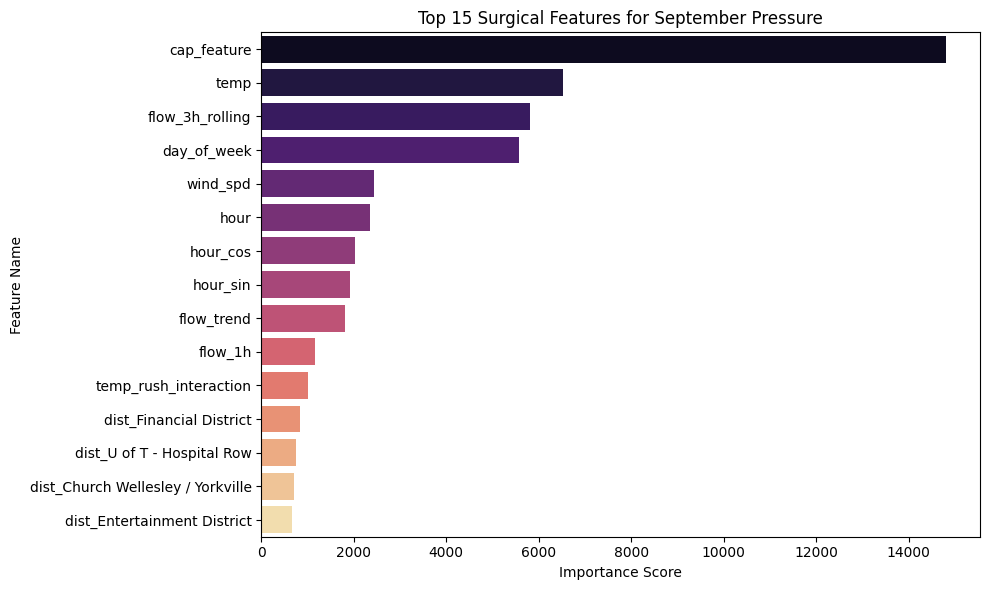

In [75]:
# 1. Extract feature importances directly from LightGBM
importances = lgb_model.feature_importances_
feature_names = X_train.columns

# 2. Create and sort the DataFrame FIRST
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

# 3. Plot cleanly sorted bars
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature', 
    palette='magma', 
    legend=False
)

plt.title('Top 15 Surgical Features for September Pressure')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

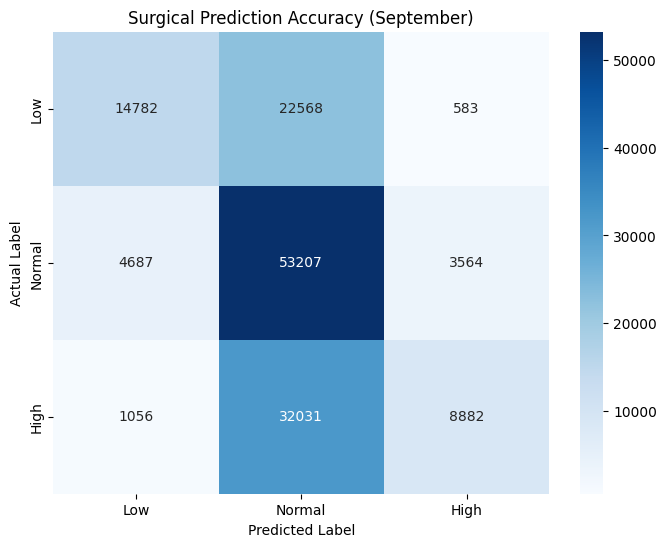

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the confusion matrix using custom_preds
cm = confusion_matrix(y_test, custom_preds)

# 2. Plot it as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Low', 'Normal', 'High'],
    yticklabels=['Low', 'Normal', 'High']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Surgical Prediction Accuracy (September)')
plt.show()

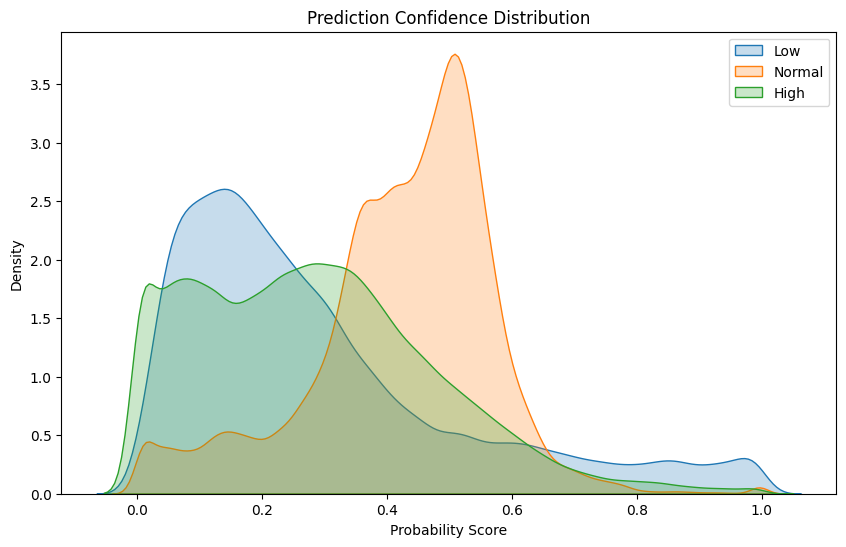

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the probabilities for each class from lgb_model
y_probs = lgb_model.predict_proba(X_test)

plt.figure(figsize=(10, 6))
for i, label in enumerate(['Low', 'Normal', 'High']):
    sns.kdeplot(y_probs[:, i], label=label, fill=True)

plt.title('Prediction Confidence Distribution')
plt.xlabel('Probability Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [80]:
# Check if weather or trends are causing unfair bias
for feature in ['temp', 'flow_trend', 'is_rush_hour']:
    correlation = ml_ready_df[[feature, 'label']].corr().iloc[0,1]
    print(f"Surgical Correlation ({feature}): {correlation:.4f}")

Surgical Correlation (temp): -0.0118
Surgical Correlation (flow_trend): 0.0080
Surgical Correlation (is_rush_hour): -0.0218


# This model is currently live and serving predictions here: 

https://surgical-pressure-predictor-7mpkvqe2pexeybrz6gcure.streamlit.app/

In [81]:
pressure_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708911 entries, 0 to 708910
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   time_hour          708911 non-null  datetime64[ns]
 1   departures         708911 non-null  float64       
 2   arrivals           708911 non-null  float64       
 3   station_id         708911 non-null  int64         
 4   net_flow           708911 non-null  float64       
 5   district           708911 non-null  object        
 6   tier               708911 non-null  object        
 7   capacity           708911 non-null  float64       
 8   current_inventory  708911 non-null  float64       
 9   target_state       708911 non-null  object        
 10  future_target_2h   708911 non-null  object        
 11  hour_sin           708911 non-null  float64       
 12  hour_cos           708911 non-null  float64       
 13  day_of_week        708911 non-null  int32   

https://github.com/BIG-JAY474/Surgical-Pressure-Predictor/blob/main/README.md